# 05 - Advanced Analytics and ML (SRS Intelligence Layer)

The Python pipeline's intelligence outputs:

1. RFM + KMeans customer segmentation
2. Menu business classes (Profit / Volume Driver, Hidden Opportunity, Low Performer)
3. Market basket (support / confidence / lift)
4. Peak-period analysis
5. Demand forecast with chronological 90-day holdout (MAE / RMSE / MAPE vs naive baseline)
6. Wastage risk
7. Price elasticity
8. Promotion effectiveness + trap detection
9. Anomaly detection
10. Slow movers
11. Location / channel intelligence
12. Churn-risk logistic regression
13. Evidence-backed recommendations
14. What-if scenarios

Also produces the **dual-pipeline comparison sets** used to compare
against the Spark MLlib pipeline (see `dual_pipeline/` in the output).


In [1]:
import sys
from pathlib import Path
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import nb_common

# ------------------------------------------------------------------
# Run mode:
#   "quick" -> demo-scale data (~20k orders) in notebook/outputs/
#   "full"  -> full SRS scale (1M lines) in the canonical repo dirs
# ------------------------------------------------------------------
MODE = "quick"

paths = nb_common.setup_paths(MODE)
nb_common.ensure_config(paths)
mk = nb_common.markers(paths)

pd.options.display.max_columns = 20
print(f"MODE: {MODE}")
print(f"raw       : {paths['raw']}")
print(f"processed : {paths['processed']}")


MODE: quick
raw       : /home/user/Techwizz/notebook/outputs/quick/raw
processed : /home/user/Techwizz/notebook/outputs/quick/processed


In [2]:
if not nb_common.step_done(*mk['generation']):
    from generate_dineiq_data import generate
    generate(raw_dir=paths['raw'], config_path=paths['config'])
if not nb_common.step_done(*mk['cleaning']):
    import clean_dineiq_data
    clean_dineiq_data.main(
        raw_dir=paths['raw'], processed_dir=paths['processed'],
        reports_dir=paths['reports'], quarantine_dir=paths['quarantine'],
        config_path=paths['config'])
if not nb_common.step_done(*mk['processing']):
    import process_dineiq_data
    process_dineiq_data.main(processed_dir=paths['processed'],
                              output_dir=paths['analytics'], reports_dir=paths['reports'])

In [3]:
import run_advanced_analytics

if not nb_common.step_done(*mk['advanced']):
    result = run_advanced_analytics.main(
        processed_dir=paths['processed'],
        output_dir=paths['analytics'],
        dual_dir=paths['dual'],
    )
else:
    print('Advanced analytics already exist - skipping.')
    result = None

DineIQ Analytics - Advanced Analytics & Intelligence Layer
Input : /home/user/Techwizz/notebook/outputs/quick/processed
Output: /home/user/Techwizz/notebook/outputs/quick/processed/analytics

Loading processed datasets...


Analysis window: 2025-01-01 to 2025-12-31 | completed orders: 15,858

[1/14] RFM analysis and customer segmentation (KMeans)...
  Saved: rfm_segmentation.csv (6,884 rows)

[2/14] Menu business classes (Profit/Volume Driver, Hidden Opportunity, Low Performer)...
  Saved: menu_business_classes.csv (150 rows)


  Saved: menu_class_unseen_cases.csv (30 rows)
  Saved: menu_class_python_predictions.csv (30 rows)

[2b/14] Order-value classification (dual-pipeline task)...


  Saved: order_value_unseen_cases.csv (300 rows)
  Saved: order_value_python_predictions.csv (300 rows)
  Saved: order_value_classification_report.csv (7 rows)

[3/14] Market-basket analysis (support / confidence / lift)...


  Saved: market_basket_pairs.csv (200 rows)

[4/14] Peak-period analysis...
  Saved: peak_period_analysis.csv (140 rows)

[5/14] Demand forecasting with chronological validation...
  Saved: daily_forecast.csv (90 rows)
  Saved: forecast_evaluation.csv (2 rows)
  Saved: forecast_unseen_days.csv (90 rows)

[6/14] Wastage and wastage-risk analysis...
  Saved: wastage_risk_analysis.csv (150 rows)

[7/14] Price sensitivity analysis (price elasticity)...
  Saved: price_sensitivity_analysis.csv (150 rows)

[8/14] Promotion effectiveness and trap detection...


  Saved: promotion_effectiveness.csv (120 rows)

[9/14] Anomaly detection (sales, order totals, ratings)...
  Saved: anomaly_detection.csv (67 rows)

[10/14] Slow-moving dish detection...


  Saved: slow_moving_items.csv (13 rows)

[11/14] Location and channel intelligence...
  Saved: location_channel_intelligence.csv (80 rows)

[12/14] Churn risk modelling (logistic regression)...


  Saved: churn_risk.csv (6,884 rows)
  Saved: churn_model_metrics.csv (9 rows)
  Saved: churn_unseen_cases.csv (200 rows)
  Saved: churn_python_predictions.csv (200 rows)

[13/14] Evidence-backed recommendations...
  Saved: recommendations.csv (20 rows)

[14/14] What-if scenario estimates...
  Saved: what_if_analysis.csv (3 rows)

ADVANCED ANALYTICS COMPLETE
Analytics output : /home/user/Techwizz/notebook/outputs/quick/processed/analytics
Dual-pipeline    : /home/user/Techwizz/notebook/outputs/quick/dual_pipeline

Forecast model MAE: 75,943 | naive MAE: 123,024 | model beats baseline: True
Churn accuracy: 100.00% | macro F1: 1.00

  - advanced_analytics_summary.csv
  - anomaly_detection.csv
  - channel_analysis.csv
  - churn_model_metrics.csv
  - churn_risk.csv
  - customer_analytics.csv
  - daily_forecast.csv
  - daily_sales.csv
  - forecast_evaluation.csv
  - inventory_integrated.csv
  - location_channel_intelligence.csv
  - market_basket_pairs.csv
  - menu_business_classes.csv
  - m

In [4]:
# 1. Demand forecast: model vs naive baseline (SRS: model must beat baseline)
ev = pd.read_csv(paths['analytics'] / 'forecast_evaluation.csv')
ev

,model,mae,rmse,mape
0,linear_regression (day-of-week + trend + movin...,75942.660573,93914.254256,14.816433
1,naive_baseline (previous day),123024.109667,153276.651755,24.330193


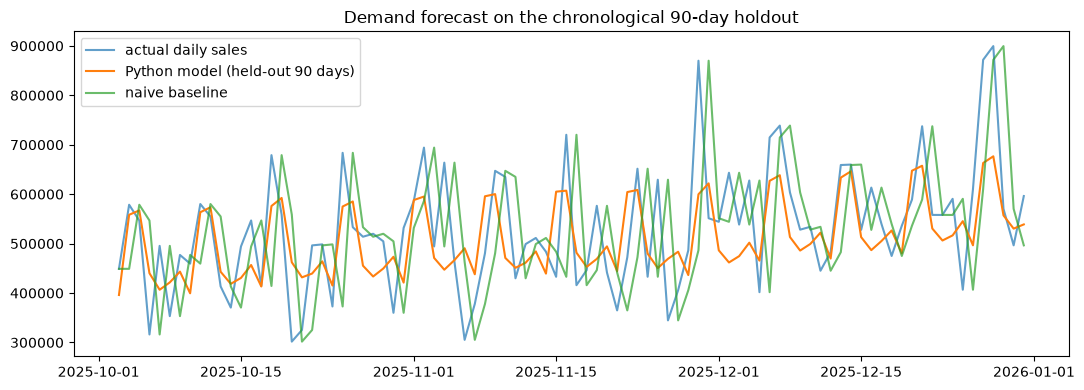

In [5]:
import matplotlib.pyplot as plt

daily = pd.read_csv(paths['analytics'] / 'daily_sales.csv', low_memory=False)
daily['order_date'] = pd.to_datetime(daily['order_date'])
fc = pd.read_csv(paths['analytics'] / 'daily_forecast.csv')
fc['date'] = pd.to_datetime(fc['date'])

recent = daily[daily['order_date'] >= fc['date'].min()]
plt.figure(figsize=(11, 4))
plt.plot(recent['order_date'], recent['total_sales'], label='actual daily sales', alpha=0.7)
plt.plot(fc['date'], fc['python_model_prediction'], label='Python model (held-out 90 days)')
plt.plot(fc['date'], fc['naive_prediction'], label='naive baseline', alpha=0.7)
plt.legend()
plt.title('Demand forecast on the chronological 90-day holdout')
plt.tight_layout()
plt.show()

In [6]:
# 2. RFM segments (KMeans)
rf = pd.read_csv(paths['analytics'] / 'rfm_segmentation.csv')
rf['segment'].value_counts()

segment
At Risk - High Value    1948
Hibernating             1450
Loyal Customers         1340
Champions               1242
Potential Loyalist       904
Name: count, dtype: int64

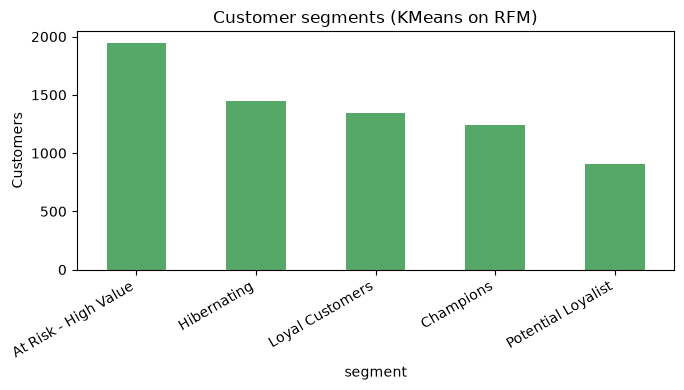

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
rf['segment'].value_counts().plot(kind='bar', color='#55A868')
plt.title('Customer segments (KMeans on RFM)')
plt.ylabel('Customers')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# 3. Menu business classes + contradictory cases
mc = pd.read_csv(paths['analytics'] / 'menu_business_classes.csv')
print(mc['business_class'].value_counts())
print()
print('Contradictory cases flagged:')
print(mc.loc[mc['contradictory_case'] != '', 'contradictory_case'].value_counts())

business_class
Low Performer         67
Profit Driver         44
Hidden Opportunity    26
Volume Driver         13
Name: count, dtype: int64

Contradictory cases flagged:
contradictory_case
High profit but heavy wastage    8
Name: count, dtype: int64


In [9]:
# 4. Market basket - top pairs by lift
mb = pd.read_csv(paths['analytics'] / 'market_basket_pairs.csv')
mb.head(8)

,item_a,item_b,pair_orders,support,p_a,p_b,confidence_a_to_b,confidence_b_to_a,lift
0,89,109,91,0.005738,0.015828,0.016522,0.362550,0.347328,21.943949
1,40,60,127,0.008009,0.019801,0.018729,0.404459,0.427609,21.595638
2,60,120,115,0.007252,0.018729,0.017972,0.387205,0.403509,21.544923
3,11,31,333,0.020999,0.037520,0.026044,0.559664,0.806295,21.489466
4,11,71,549,0.034620,0.037520,0.042944,0.922689,0.806167,21.486055
5,51,91,341,0.021503,0.025981,0.038593,0.827670,0.557190,21.446388
6,11,131,539,0.033989,0.037520,0.042250,0.905882,0.804478,21.441018
7,71,131,616,0.038845,0.042944,0.042250,0.904552,0.919403,21.409534


In [10]:
# 8. Promotion effectiveness and traps
pe = pd.read_csv(paths['analytics'] / 'promotion_effectiveness.csv')
print('promotions:', len(pe), '| with usage:', int((pe['promo_orders'] > 0).sum()), '| traps:', int(pe['promotion_trap'].sum()))
pe.sort_values('incremental_revenue_estimate', ascending=False).head(5)[
    ['promotion_id', 'restaurant_id', 'promo_orders', 'aov_lift_percentage', 'incremental_revenue_estimate', 'promotion_trap']
]

promotions: 120 | with usage: 120 | traps: 88


,promotion_id,restaurant_id,promo_orders,aov_lift_percentage,incremental_revenue_estimate,promotion_trap
0,108,12,38,4.25,33316.60,False
1,20,2,26,6.31,27583.21,False
2,88,2,19,7.51,24517.88,False
3,74,18,18,8.95,12246.95,False
4,3,17,20,4.94,11418.13,False


In [11]:
# 12. Churn model metrics
pd.read_csv(paths['analytics'] / 'churn_model_metrics.csv')

,metric,value
0,accuracy,1.0
1,roc_auc,1.0
2,macro_f1,1.0
3,train_size,3923
4,test_size,981
5,churn_rate,0.6917
6,definition,No completed order in the final 60 days of the...
7,observation_window,Customers with first order on or before 2025-0...
8,model,LogisticRegression (sklearn)


In [12]:
churn = pd.read_csv(paths['analytics'] / 'churn_risk.csv')
churn['churn_risk'].value_counts()

churn_risk
High    4382
Low     2502
Name: count, dtype: int64

In [13]:
# 13. Evidence-backed recommendations (top of each priority)
rec = pd.read_csv(paths['analytics'] / 'recommendations.csv', low_memory=False)
rec[['priority', 'recommendation', 'target_name', 'estimated_impact']].head(10)

,priority,recommendation,target_name,estimated_impact
0,P1,"Promote high-margin, low-volume item (bundle, ...",Menu Item 030 @ Restaurant 010,Each extra 100 units adds ~30797 currency unit...
1,P1,"Promote high-margin, low-volume item (bundle, ...",Menu Item 147 @ Restaurant 007,Each extra 100 units adds ~37785 currency unit...
2,P1,"Promote high-margin, low-volume item (bundle, ...",Menu Item 033 @ Restaurant 013,Each extra 100 units adds ~55086 currency unit...
3,P1,"Promote high-margin, low-volume item (bundle, ...",Menu Item 134 @ Restaurant 014,Each extra 100 units adds ~45082 currency unit...
4,P1,"Promote high-margin, low-volume item (bundle, ...",Menu Item 106 @ Restaurant 006,Each extra 100 units adds ~42447 currency unit...
5,P2,Pause or restructure underperforming promotion,Promotion 037,Recovers discount spend without incremental re...
6,P2,Pause or restructure underperforming promotion,Promotion 008,Recovers discount spend without incremental re...
7,P2,Pause or restructure underperforming promotion,Promotion 065,Recovers discount spend without incremental re...
8,P2,Reduce overproduction / tighten prep planning,Menu Item 025 @ restaurant 5,30% waste reduction saves ~66904
9,P2,Reduce overproduction / tighten prep planning,Menu Item 055 @ restaurant 15,30% waste reduction saves ~61553


In [14]:
# 14. What-if scenarios
pd.read_csv(paths['analytics'] / 'what_if_analysis.csv')[[
    'scenario', 'scope', 'price_change_percentage', 'affected_items',
    'revenue_change', 'profit_change'
]]

,scenario,scope,price_change_percentage,affected_items,revenue_change,profit_change
0,price_increase_10pct,Volume Driver,10,13,-75071.05,362204.57
1,price_decrease_10pct,Hidden Opportunity,-10,26,-100788.16,-522108.10
2,discount_15pct,Low Performer,-15,67,-11189731.59,-11103248.13


In [15]:
# Dual-pipeline comparison sets (Python side)
from pathlib import Path
for f in sorted(Path(paths['dual']).glob('*.csv')):
    print(f'{f.name:45s} {len(pd.read_csv(f, low_memory=False)):>6d} rows')

churn_python_predictions.csv                     200 rows
churn_unseen_cases.csv                           200 rows
forecast_unseen_days.csv                          90 rows
menu_class_python_predictions.csv                 30 rows
menu_class_unseen_cases.csv                       30 rows
order_value_classification_report.csv              7 rows
order_value_python_predictions.csv               300 rows
order_value_unseen_cases.csv                     300 rows


**Dual-pipeline handoff:** the files above (plus the README in the
dual-pipeline directory) are the Python side of the SRS comparison.
The Spark pipeline independently predicts the **same unseen cases**
(primary task: 300 high-value order cases) and the two sides are
compared record by record: matches, disagreements with
explanations, and the agreement percentage.
